1. Import all Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2.Load dataset

In [ ]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

3. check data and oversee the data for the basic understanding

In [ ]:
# looking for number of rows and column
df.shape

(5000, 13)

In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


4. Exploratory Data Analysis

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

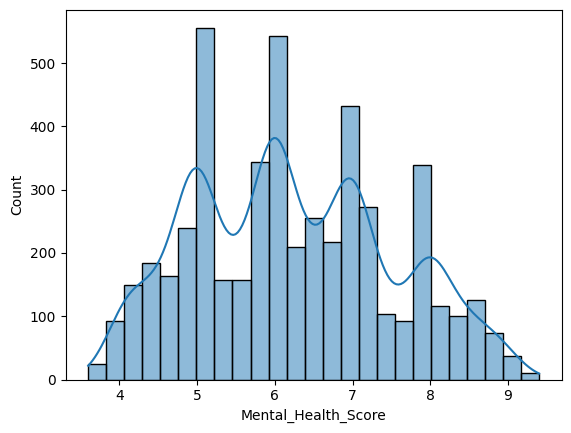

In [ ]:
# distribution of target(Mental_health_score)
sns.histplot(df['Mental_Health_Score'], kde=True)

<Axes: >

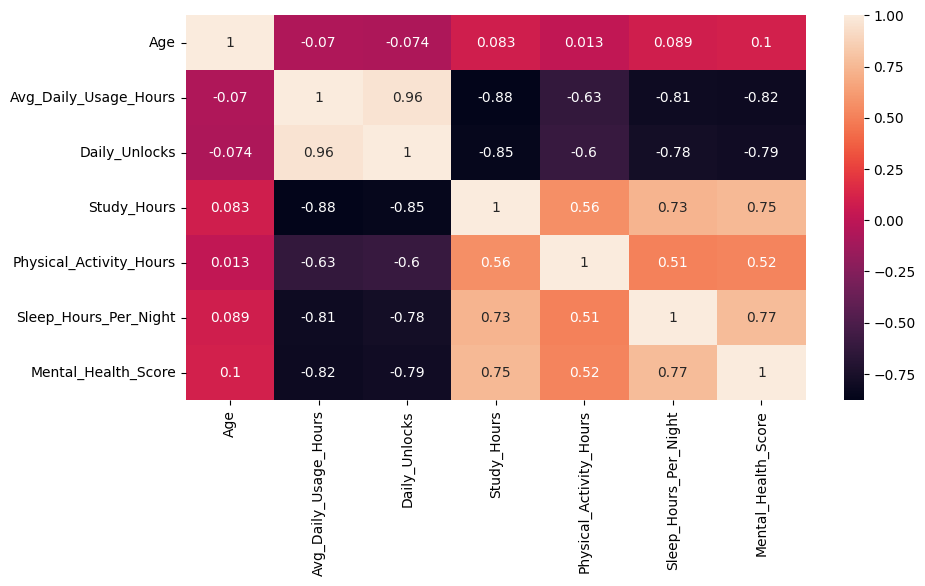

In [ ]:
#corelation heatmap
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [ ]:
# strees level vs Mental Health Score
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

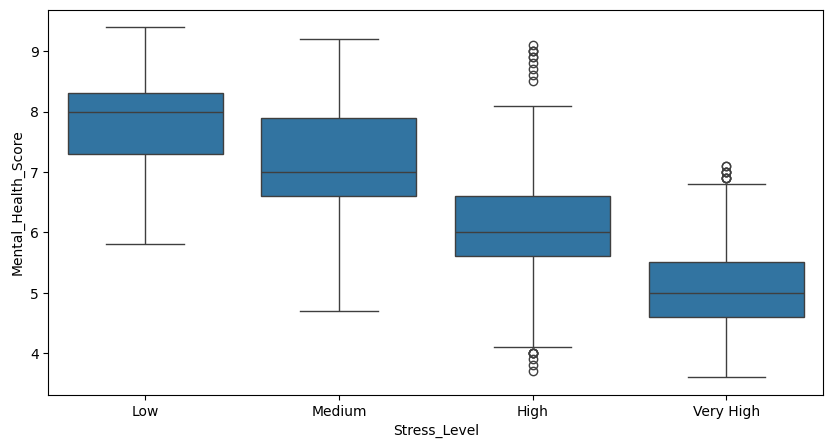

In [ ]:
order = ['Low','Medium','High','Very High' ]
plt.figure(figsize=(10,5))
sns.boxplot(x='Stress_Level',  y='Mental_Health_Score',data=df,order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

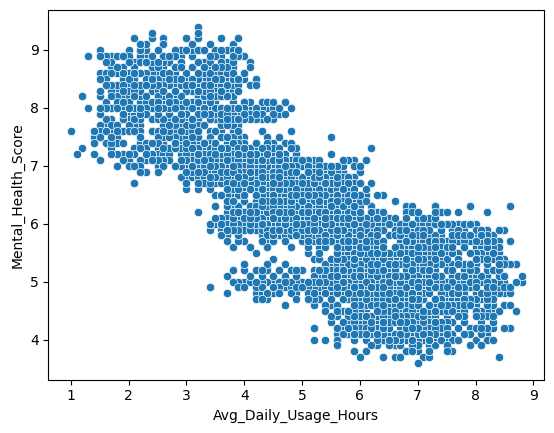

In [ ]:
# Daily Usages hour vs stress level
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

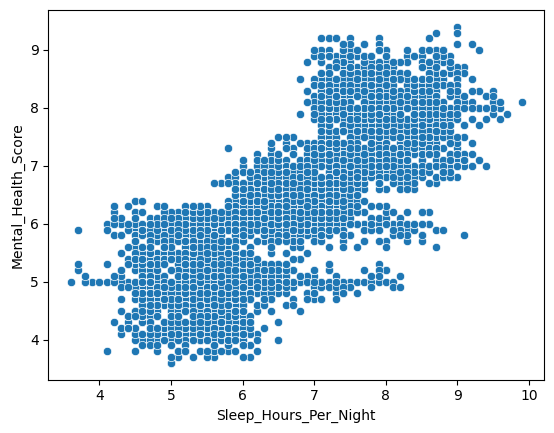

In [ ]:
# sleep hour vs mental healt score
sns.scatterplot(x='Sleep_Hours_Per_Night', y= 'Mental_Health_Score',data=df)

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

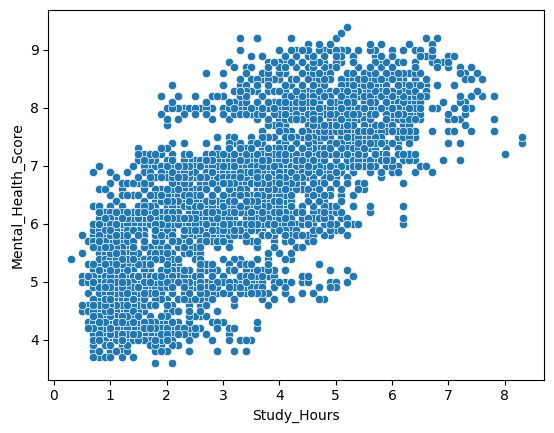

In [ ]:
# study hours vs mental health score
sns.scatterplot(x='Study_Hours',y='Mental_Health_Score',data=df)

In [ ]:
platform_counts = df['Most_Used_Platform'].value_counts()
platform_counts

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


<Axes: xlabel='Most_Used_Platform', ylabel='count'>

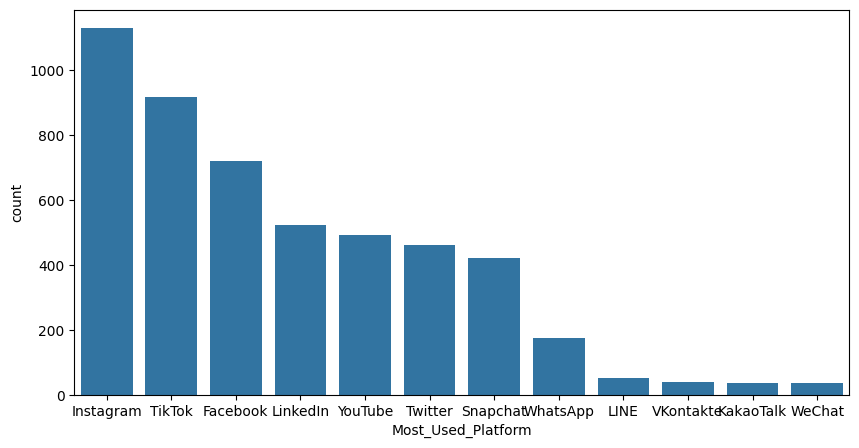

In [ ]:
# most used platform
plt.figure(figsize=(10,5))
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

In [ ]:
 # checking outliers
num_features = df.select_dtypes(include=np.number)
num_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [ ]:
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


5. Data cleaning

In [ ]:
# 1. drop the duplicates
df = df.drop_duplicates()

#2. converting negative and unrealistic value to realistic value
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


6. Skewness

In [ ]:
num_col = df.select_dtypes(include='number')
num_col.skew()
# near to zero -> centeralized
# negative -> left skewed
#positive (greter than zero) -> right skewed
# fix using log transformation

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [ ]:
# Feature Engineering
top_countries = df['Country'].value_counts().index[:10].tolist()

In [ ]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [ ]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [ ]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


Encoding Strategy

9. Train test split

In [ ]:
df.columns


Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_country'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
skewed_col             = ['Study_Hours']
other_numeric_columns = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                         "Sleep_Hours_Per_Night"]
ordinal_col           = ['Stress_Level']
normal_col            = ["Gender","Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

features_col = skewed_col + other_numeric_columns + ordinal_col + normal_col
X = df[features_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

10. Preprocessing and Pipeline

In [ ]:
from seaborn._core.typing import ColumnName
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
#1. skewed pipeline
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

#2. Numeric feature
plain_numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

#3. Ordinal
Ordinal_pipeline = Pipeline(steps=[
    ('encoder', OrdinalEncoder(categories=[['Low','Medium', 'High', 'Very High', ]]))
])

#4. Nominal features
Nominal_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# column Transfer.  kon si pipeline mai kon si features dalna hai
preprocessor = ColumnTransformer(transformers=[
    ('skew_pipeline', skew_pipeline, skewed_col),
    ('plain_numeric_pipeline', plain_numeric_pipeline, other_numeric_columns),
    ('Ordinal_pipeline', Ordinal_pipeline, ordinal_col),
    ('Nominal_pipeline', Nominal_pipeline, normal_col)
])
preprocessor

ColumnTransformer(transformers=[('skew_pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours']),
                                ('plain_numeric_pipeline',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal_pipeline',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('Nominal_pipeline',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Grouped_country'])])

11.Build a pipeline

12. Build a Model

In [ ]:
# 1 Baseline: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor_model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_pred_train = lr_pipeline.predict(X_train)

# evaluation
# for test data
lr_r2 = r2_score(y_test, lr_pred)
lr_mae_test = mean_absolute_error(y_test, lr_pred)
# for y data
lr_r2_train = r2_score(y_train, lr_pred_train)
lr_mae_train = mean_absolute_error(y_train, lr_pred_train)

print(f"accurecy of testing : {lr_r2}")
print(f"accurecy of traing : {lr_r2_train}")
print(f"mae of testing : {lr_mae_test}")
print(f"mae of traing : {lr_mae_train}")


accurecy of testing : 0.7397944617433021
accurecy of traing : 0.7236771199387538
mae of testing : 0.5361775634720181
mae of traing : 0.5189846926901907


In [ ]:
# 2 Random forest
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor_model', RandomForestRegressor())
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_pred_train = rf_pipeline.predict(X_train)

# evaluation
rf_r2 = r2_score(y_test, rf_pred)
rf_mae_test = mean_absolute_error(y_test, rf_pred)
rf_r2_train = r2_score(y_train, rf_pred_train)
rf_mae_train = mean_absolute_error(y_train, rf_pred_train)

print(f"accurecy of testing : {rf_r2}")
print(f"accurecy of training : {rf_r2_train}")
print(f"mae of testing : {rf_mae_test}")
print(f"mae of traing : {rf_mae_train}")

accurecy of testing : 0.8780147724944042
accurecy of training : 0.9808042248453256
mae of testing : 0.3462873333333335
mae of traing : 0.12596559462550036


In [ ]:
#3. Hyperparameter tuning
param_grid = {
    'regressor_model__n_estimators': [100, 200, 300],
    'regressor_model__max_depth': [10, 15, 20],
    'regressor_model__min_samples_split': [2, 5, 10],
    'regressor_model__min_samples_leaf': [1, 2, 4]
}
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor_model', RandomForestRegressor())
])

random_search = RandomizedSearchCV(estimator=rf_pipeline,
                                   param_distributions=param_grid,
                                   n_iter = 15,
                                   cv = 5,
                                   scoring= 'r2',
                                   random_state= 42,
                                   n_jobs= -1) # proseccor free
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew_pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric_pipeline',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unl...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('regressor_model',
                                              RandomForestRegressor())]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'regressor_model__max_depth': [10, 15,
                                                                       20],
                                        'regressor_model__min_samples_leaf': [1,
                                                                              2,
                                                                              4],
                                        'regressor_model__min_samples_split': [2,
                                                                               5,
                                                                               10],
                                        'regressor_model__n_estimators': [100,
                                                                          200,
                                                                          300]},
                   random_state=42, scoring='r2')

In [ ]:
random_search.best_params_

{'regressor_model__n_estimators': 200,
 'regressor_model__min_samples_split': 2,
 'regressor_model__min_samples_leaf': 1,
 'regressor_model__max_depth': 15}

In [ ]:
rf_best_pipeline = random_search.best_estimator_
rf_best_pipeline.fit(X_train, y_train)
rf_best_pred = rf_best_pipeline.predict(X_test)
rf_best_pred_train = rf_best_pipeline.predict(X_train)

# evaluation
rf_best_r2 = r2_score(y_test, rf_best_pred)
rf_best_mae_test = mean_absolute_error(y_test, rf_best_pred)

# for training data
rf_best_r2_train = r2_score(y_train, rf_best_pred_train)
rf_best_mae_train = mean_absolute_error(y_train, rf_best_pred_train)


print(f"accurecy of testing after hyperparameter : {rf_best_r2}")
print(f"mae of testing after Hyperparameter : {rf_best_mae_test}")
print(f"accurecy of training after hyperparameter : {rf_best_r2_train}")
print(f"mae of training after hyperparameter : {rf_best_mae_train}")

accurecy of testing after hyperparameter : 0.8734240579062217
mae of testing after Hyperparameter : 0.357372433434871
accurecy of training after hyperparameter : 0.9688248913347173
mae of training after hyperparameter : 0.16725107168535544


13. Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# calculate RMSE fro Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# clculate for default Random forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# calculate for best Random forest
rf_best_rmse = np.sqrt(mean_squared_error(y_test, rf_best_pred))

# create a dataframe to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Default Random Forest', 'tuned Random Forest'],
    'RMSE': [lr_rmse, rf_rmse, rf_best_rmse],
    'R2_test': [lr_r2, rf_r2, rf_best_r2],
    'R2_train': [lr_r2_train, rf_r2_train, rf_best_r2_train],
    'MAE': [lr_mae_test, rf_mae_test, rf_best_mae_test]
})

# display the results
print(results)


                   Model      RMSE   R2_test  R2_train       MAE
0      Linear Regression  0.676032  0.739794  0.723677  0.536178
1  Default Random Forest  0.462874  0.878015  0.980804  0.346287
2    tuned Random Forest  0.471503  0.873424  0.968825  0.357372


14. Save the model

In [ ]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']